# 06 — EDA Portfolio Overview

## Objective
Perform the first transversal exploratory analysis of the SecureHealth portfolio using:

- member_master.csv
- claims_analytical_base.csv
- provider_master.csv

This notebook will generate:
- portfolio KPIs
- first segmentation views
- initial business insights

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: C:\Users\dolivares\Desktop\novares-securehealth


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.config import PROCESSED_DIR

In [3]:
## Load processed analytical tables
member_master = pd.read_csv(PROCESSED_DIR / "member_master.csv")
claims_analytical_base = pd.read_csv(PROCESSED_DIR / "claims_analytical_base.csv")
provider_master = pd.read_csv(PROCESSED_DIR / "provider_master.csv")

print("member_master:", member_master.shape)
print("claims_analytical_base:", claims_analytical_base.shape)
print("provider_master:", provider_master.shape)

member_master: (4000, 63)
claims_analytical_base: (44144, 107)
provider_master: (180, 39)


In [4]:
display(member_master.head(3))
display(claims_analytical_base.head(3))
display(provider_master.head(3))

,member_id,policy_id,join_date,age,age_band,sex,region,city_tier,socioeconomic_band,employment_status,...,sales_channel,broker_id,tenure_days,tenure_months_approx,premium_gap,has_dependents_flag,high_chronic_burden_flag,high_baseline_risk_flag,high_utilization_propensity_flag,high_misuse_exposure_flag
0,MBR000001,POL000001,2022-09-24,47,45-54,M,San Pedro,Urban,Upper-Middle,Self-Employed,...,Corporate,NaN,1559,51.3,4.547474e-13,0,0,1,1,1
1,MBR000002,POL000002,2024-04-02,35,35-44,F,San Pedro,Metro,Lower-Middle,Employed,...,Direct,NaN,1003,33.0,4.547474e-13,0,0,0,0,0
2,MBR000003,POL000003,2024-06-27,65,65+,M,Asunción,Urban,Middle,Self-Employed,...,Direct,NaN,917,30.2,-9.094947e-13,1,0,1,1,0


,claim_id,member_id,policy_id,provider_id,claim_date,claim_year,claim_month,service_type,service_category,diagnosis_group,...,contract_type,base_cost_multiplier,diagnostic_intensity,admission_intensity,average_claim_expected,historical_volume_band,historical_suspicion_flag,provider_quality_proxy,fraud_exposure_score,premium_gap
0,CLM000000350,MBR001287,POL001287,PRV00080,2024-01-01,2024,2024-01,Diagnostics,Laboratory,General,...,Standard,0.892698,Low,Medium,197.96,High,0,High,0.197,4.547474e-13
1,CLM000000547,MBR001823,POL001823,PRV00129,2024-01-01,2024,2024-01,Diagnostics,Diagnostics,Preventive,...,Standard,1.552278,Low,Medium,388.66,Low,0,Low,0.292,0.000000e+00
2,CLM000000911,MBR003002,POL003002,PRV00110,2024-01-01,2024,2024-01,Outpatient,Follow-up Consultation,Minor Acute,...,Preferred,1.044202,Medium,Medium,201.38,High,0,Low,0.227,0.000000e+00


,provider_id,provider_name,provider_type,specialty_group,region,city_tier,network_status,provider_archetype,contract_type,base_cost_multiplier,...,dx_proc_mismatch_n_mean,high_severity_share_mean,suspicious_claim_ratio_mean,cost_vs_peer_index_mean,utilization_density_index_mean,anomaly_score_provider_mean,claims_count,high_claim_volume_flag,high_fraud_exposure_flag,high_cost_provider_flag
0,PRV00001,Provider 1,Clinic,Pediatrics,Central,Metro,In-network,Normal,External,1.003462,...,0.0,0.068750,0.065875,0.769750,1.008375,0.050250,363,0,0,0
1,PRV00002,Provider 2,Specialist Center,Pulmonology,Asunción,Semi-Urban,In-network,Normal,Standard,1.082438,...,0.0,0.091667,0.061792,0.862542,1.000000,0.055875,168,0,0,0
2,PRV00003,Provider 3,Pharmacy,Pharmacy,Asunción,Urban,In-network,High Complexity,Standard,1.577247,...,0.0,0.046875,0.072917,1.010125,1.000000,0.088875,89,0,0,1


In [5]:
## Portfolio KPIs
kpis = {
    "insured_members": len(member_master),
    "active_policies": int(member_master["active_flag"].sum()) if "active_flag" in member_master.columns else np.nan,
    "renewal_rate": round(member_master["renewal_flag"].mean(), 4) if "renewal_flag" in member_master.columns else np.nan,
    "cancellation_rate": round(member_master["cancellation_flag"].mean(), 4) if "cancellation_flag" in member_master.columns else np.nan,
    "avg_monthly_premium": round(member_master["premium_monthly"].mean(), 2) if "premium_monthly" in member_master.columns else np.nan,
    "total_annual_premium": round(member_master["premium_annual"].sum(), 2) if "premium_annual" in member_master.columns else np.nan,
    "providers_n": provider_master["provider_id"].nunique() if "provider_id" in provider_master.columns else np.nan,
    "claims_n": len(claims_analytical_base),
}

pd.DataFrame(kpis.items(), columns=["metric", "value"])

,metric,value
0,insured_members,4.000000e+03
1,active_policies,4.000000e+03
2,renewal_rate,8.468000e-01
3,cancellation_rate,5.850000e-02
4,avg_monthly_premium,3.827200e+02
5,total_annual_premium,1.837079e+07
6,providers_n,1.800000e+02
7,claims_n,4.414400e+04


In [8]:
## Member composition
display(
    member_master["age_band"]
    .value_counts(dropna=False)
    .rename_axis("age_band")
    .reset_index(name="count")
)

display(
    member_master["sex"]
    .value_counts(dropna=False)
    .rename_axis("sex")
    .reset_index(name="count")
)

display(
    member_master["region"]
    .value_counts(dropna=False)
    .rename_axis("region")
    .reset_index(name="count")
)

,age_band,count
0,35-44,1228
1,25-34,908
2,45-54,715
3,55-64,402
4,65+,399
5,18-24,348


,sex,count
0,F,2030
1,M,1970


,region,count
0,Central,1176
1,Asunción,867
2,Alto Paraná,578
3,Itapúa,423
4,Cordillera,311
5,Caaguazú,250
6,San Pedro,202
7,Paraguarí,193


In [9]:
display(
    member_master["archetype"]
    .value_counts(dropna=False)
    .rename_axis("archetype")
    .reset_index(name="count")
)

display(
    member_master["plan_type"]
    .value_counts(dropna=False)
    .rename_axis("plan_type")
    .reset_index(name="count")
)

display(
    member_master["plan_tier"]
    .value_counts(dropna=False)
    .rename_axis("plan_tier")
    .reset_index(name="count")
)

,archetype,count
0,Healthy Low User,1214
1,Preventive User,867
2,Family Planner,719
3,Chronic Managed,708
4,High Acute Risk,321
5,Hyper-Utilizer / Misuse Risk,171


,plan_type,count
0,Essential,1214
1,Standard,867
2,Family Plus,719
3,Chronic Care,708
4,High Protection,321
5,Managed Review,171


,plan_tier,count
0,Mid,1757
1,Basic,1214
2,Premium,1029


In [10]:
## Risk and propensity distributions
risk_cols = [c for c in [
    "baseline_risk_score",
    "utilization_propensity",
    "acute_event_propensity",
    "misuse_exposure_propensity",
    "price_sensitivity"
] if c in member_master.columns]

member_master[risk_cols].describe()

,baseline_risk_score,utilization_propensity,acute_event_propensity,misuse_exposure_propensity
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.303111,0.365706,0.162906,0.098809
std,0.228414,0.216575,0.181284,0.138819
min,0.050000,0.050000,0.030000,0.010000
25%,0.142000,0.204000,0.075000,0.046000
50%,0.201500,0.324000,0.107000,0.071000
75%,0.421250,0.469000,0.152250,0.096000
max,0.899000,0.979000,0.918000,0.918000


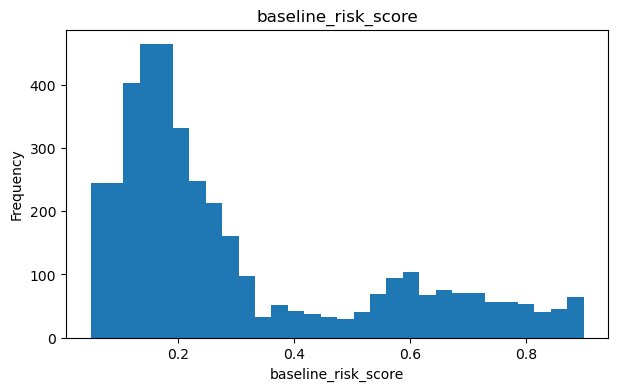

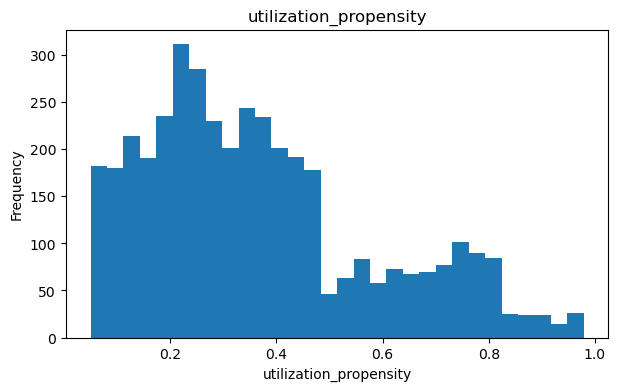

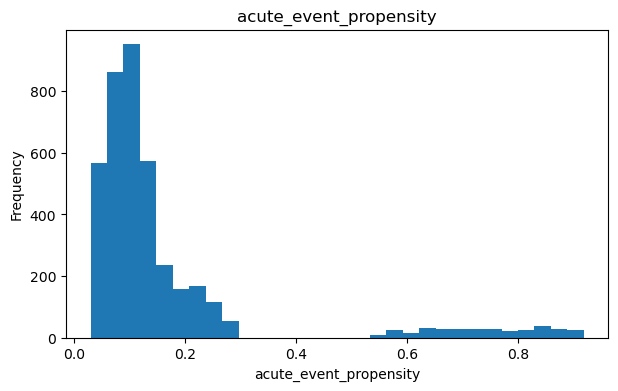

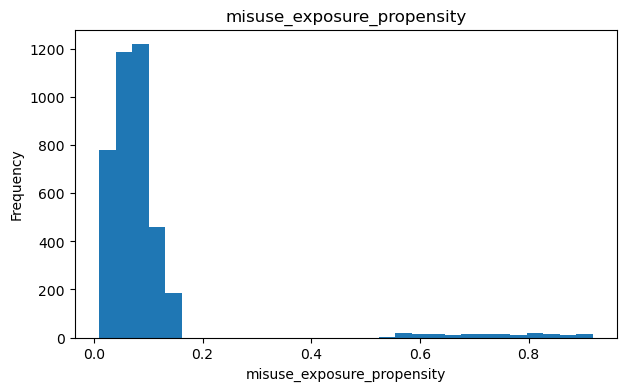

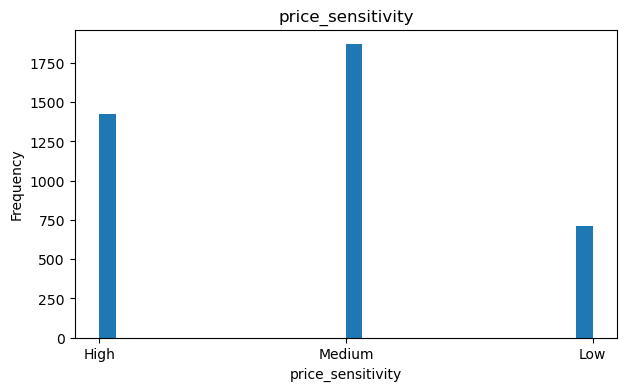

In [11]:
for col in risk_cols:
    plt.figure(figsize=(7,4))
    plt.hist(member_master[col].dropna(), bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [12]:
## Premium analysis
premium_cols = [c for c in ["premium_monthly", "premium_annual", "pricing_adequacy_ratio"] if c in member_master.columns]
member_master[premium_cols].describe()

,premium_monthly,premium_annual,pricing_adequacy_ratio
count,4000.000000,4000.000000,4000.000000
mean,382.724860,4592.698320,1.050730
std,194.615118,2335.381416,0.174028
min,120.010000,1440.120000,0.750000
25%,203.067500,2436.810000,0.898000
50%,354.515000,4254.180000,1.053000
75%,540.165000,6481.980000,1.202250
max,897.500000,10770.000000,1.350000


In [13]:
if "plan_type" in member_master.columns and "premium_monthly" in member_master.columns:
    display(
        member_master.groupby("plan_type")["premium_monthly"]
        .agg(["count", "mean", "median", "min", "max"])
        .sort_values("mean", ascending=False)
        .reset_index()
    )

if "archetype" in member_master.columns and "premium_monthly" in member_master.columns:
    display(
        member_master.groupby("archetype")["premium_monthly"]
        .agg(["count", "mean", "median"])
        .sort_values("mean", ascending=False)
        .reset_index()
    )

,plan_type,count,mean,median,min,max
0,High Protection,321,693.355888,691.350,500.82,897.50
1,Chronic Care,708,592.272613,590.475,420.31,759.58
2,Family Plus,719,496.434951,494.720,350.91,649.28
3,Managed Review,171,371.913041,380.030,262.94,479.87
4,Standard,867,300.686205,301.320,220.57,379.93
5,Essential,1214,171.148591,171.405,120.01,219.98


,archetype,count,mean,median
0,High Acute Risk,321,693.355888,691.350
1,Chronic Managed,708,592.272613,590.475
2,Family Planner,719,496.434951,494.720
3,Hyper-Utilizer / Misuse Risk,171,371.913041,380.030
4,Preventive User,867,300.686205,301.320
5,Healthy Low User,1214,171.148591,171.405


In [14]:
## Claims overview
claim_cost_col = None
for candidate in ["claim_amount", "paid_amount", "approved_amount", "amount_paid", "cost_amount", "total_cost"]:
    if candidate in claims_analytical_base.columns:
        claim_cost_col = candidate
        break

print("Detected claim cost column:", claim_cost_col)

Detected claim cost column: None


In [15]:
if claim_cost_col is not None:
    display(claims_analytical_base[claim_cost_col].describe())

    if "provider_type" in claims_analytical_base.columns:
        display(
            claims_analytical_base.groupby("provider_type")[claim_cost_col]
            .agg(["count", "mean", "median", "sum"])
            .sort_values("sum", ascending=False)
            .reset_index()
        )

In [16]:
## Provider overview
provider_cols = [c for c in [
    "base_cost_multiplier",
    "diagnostic_intensity",
    "admission_intensity",
    "fraud_exposure_score",
    "claims_count",
    "claim_cost_mean",
    "claim_cost_sum"
] if c in provider_master.columns]

provider_master[provider_cols].describe()

,base_cost_multiplier,fraud_exposure_score,claims_count
count,180.000000,180.000000,180.000000
mean,1.217640,0.280950,245.244444
std,0.282473,0.180704,144.188720
min,0.850000,0.120000,60.000000
25%,1.000581,0.183750,94.000000
50%,1.106078,0.226500,253.500000
75%,1.418722,0.300250,389.000000
max,2.314093,0.929000,444.000000


In [17]:
if "provider_type" in provider_master.columns and "fraud_exposure_score" in provider_master.columns:
    display(
        provider_master.groupby("provider_type")["fraud_exposure_score"]
        .agg(["count", "mean", "median"])
        .sort_values("mean", ascending=False)
        .reset_index()
    )

,provider_type,count,mean,median
0,Specialist Center,17,0.349000,0.2380
1,Hospital,36,0.321417,0.2825
2,Imaging,16,0.304812,0.2195
3,Lab,27,0.258963,0.2370
4,Clinic,54,0.257611,0.2230
5,Pharmacy,30,0.242900,0.2130


In [18]:
## Cross-segment views
if {"archetype", "plan_type", "premium_monthly"}.issubset(member_master.columns):
    cross_1 = (
        member_master.groupby(["archetype", "plan_type"])["premium_monthly"]
        .agg(["count", "mean"])
        .reset_index()
        .sort_values(["archetype", "mean"], ascending=[True, False])
    )
    display(cross_1.head(30))

,archetype,plan_type,count,mean
0,Chronic Managed,Chronic Care,708,592.272613
1,Family Planner,Family Plus,719,496.434951
2,Healthy Low User,Essential,1214,171.148591
3,High Acute Risk,High Protection,321,693.355888
4,Hyper-Utilizer / Misuse Risk,Managed Review,171,371.913041
5,Preventive User,Standard,867,300.686205


In [19]:
if {"region", "baseline_risk_score"}.issubset(member_master.columns):
    cross_2 = (
        member_master.groupby("region")["baseline_risk_score"]
        .agg(["count", "mean", "median"])
        .reset_index()
        .sort_values("mean", ascending=False)
    )
    display(cross_2)

,region,count,mean,median
4,Cordillera,311,0.324881,0.2170
7,San Pedro,202,0.311748,0.2105
2,Caaguazú,250,0.304396,0.1990
1,Asunción,867,0.302358,0.1980
3,Central,1176,0.302276,0.2055
0,Alto Paraná,578,0.302170,0.2035
6,Paraguarí,193,0.301632,0.2010
5,Itapúa,423,0.288043,0.1980


In [20]:
## First business insights

In [21]:
insights = [
    "The repository already supports a first portfolio-level executive view.",
    "member_master enables immediate segmentation by demographic profile, archetype, and plan structure.",
    "claims_analytical_base supports the first views of cost concentration and provider mix.",
    "provider_master is ready to support future anomaly and fraud-oriented profiling."
]

for i, insight in enumerate(insights, 1):
    print(f"{i}. {insight}")

1. The repository already supports a first portfolio-level executive view.
2. member_master enables immediate segmentation by demographic profile, archetype, and plan structure.
3. claims_analytical_base supports the first views of cost concentration and provider mix.
4. provider_master is ready to support future anomaly and fraud-oriented profiling.
